# pclass와 age 그리고 gender를 기준으로 전처리
# family 사이즈 추가

- Surived:0=사망, 1=생존
- Pclass: 1=1등석, 2=2등석, 3=3등석
- gender:male=남성, female=여성
- Age: 나이
- SibSp: 타이타닉 호에 동승한 자매/배우자의 수
- Parch: 타이타닉 호에 동승한 부모/자식의 수
- Ticket: 티켓 번호 X
- Fare: 승객 요금 X
- Embarked: 탑승지; C=셰르부르, Q=퀴즈타운, S=사우샘프턴 => 상관관계 X

In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# train data
df_train = pd.read_csv("./train.csv", encoding="utf-8")

# test data
df_test = pd.read_csv("./test.csv", encoding="utf-8")

df_train.info(), df_train.shape

<class 'pandas.DataFrame'>
RangeIndex: 916 entries, 0 to 915
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerid  916 non-null    int64  
 1   survived     916 non-null    int64  
 2   pclass       916 non-null    int64  
 3   name         916 non-null    str    
 4   gender       916 non-null    str    
 5   age          736 non-null    float64
 6   sibsp        916 non-null    int64  
 7   parch        916 non-null    int64  
 8   ticket       916 non-null    str    
 9   fare         916 non-null    float64
 10  cabin        198 non-null    str    
 11  embarked     915 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 86.0 KB


(None, (916, 12))

In [4]:
df_test.info(), df_test.shape   

<class 'pandas.DataFrame'>
RangeIndex: 393 entries, 0 to 392
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerid  393 non-null    int64  
 1   pclass       393 non-null    int64  
 2   name         393 non-null    str    
 3   gender       393 non-null    str    
 4   age          310 non-null    float64
 5   sibsp        393 non-null    int64  
 6   parch        393 non-null    int64  
 7   ticket       393 non-null    str    
 8   fare         392 non-null    float64
 9   cabin        97 non-null     str    
 10  embarked     392 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 33.9 KB


(None, (393, 11))

In [5]:
df_test_copy = df_test.copy()
df_train_copy = df_train.copy()

In [6]:
df_test_copy.shape, df_test_copy.shape

((393, 11), (393, 11))

In [7]:
# FamilySize 생성
df_train_copy["familysize"] = df_train_copy["sibsp"] + df_train_copy["parch"] + 1
df_test_copy["familysize"] = df_test_copy["sibsp"] + df_test_copy["parch"] + 1


# 불필요 컬럼 제거
df_train_copy.drop(columns=["cabin","embarked","ticket","fare","name", 'sibsp', 'parch'],inplace=True)
df_test_copy.drop(columns=["cabin","embarked","ticket","fare","name", 'sibsp', 'parch'],inplace=True)

In [8]:
def family_group(size):
    if size == 1:
        return "alone"
    elif size <= 4:
        return "small"
    else:
        return "large"

df_train_copy["family_group"] = df_train_copy["familysize"].apply(family_group)
df_test_copy["family_group"] = df_test_copy["familysize"].apply(family_group)

In [9]:
df_test_copy.columns, df_test_copy.shape

(Index(['passengerid', 'pclass', 'gender', 'age', 'familysize', 'family_group'], dtype='str'),
 (393, 6))

In [10]:
bins = [0,10,20,30,40,50,60,70,80]
# age들을 묶을 카테고리 설정
labels = ["0-10","10-20","20-30","30-40","40-50","50-60","60-70","70-80"]

# age_group 이라는 이름을 추가해서 나이대별을 10씩 묶음 EX) 13->10-20 / 23->20-30 
df_test_copy["age_group"] = pd.cut(df_test_copy["age"], bins=bins, labels=labels)
df_train_copy["age_group"] = pd.cut(df_train_copy["age"], bins=bins, labels=labels)

In [11]:
df_train_copy.head()

,passengerid,survived,pclass,gender,age,familysize,family_group,age_group
0,0,0,2,male,NaN,1,alone,NaN
1,1,0,3,female,NaN,1,alone,NaN
2,2,1,1,female,52.0,3,small,50-60
3,3,1,3,male,27.0,1,alone,20-30
4,4,0,2,male,44.0,2,small,40-50


In [12]:
df_train_copy["gender"] = df_train_copy["gender"].map({
    "male":0,
    "female":1
})
df_test_copy["gender"] = df_test_copy["gender"].map({
    "male":0,
    "female":1
})

In [13]:
# df_group이라는 데이터 프레임으로 복사 후 저장
# df_train_copy = df_train_copy.drop(columns = ["age_group"])
# df_test_copy = df_test_copy.drop(columns = ["age_group"])
# = df_train_copy[["gender","age_group","survived","pclass"]].copy()

In [14]:
df_train_copy.head()

,passengerid,survived,pclass,gender,age,familysize,family_group,age_group
0,0,0,2,0,NaN,1,alone,NaN
1,1,0,3,1,NaN,1,alone,NaN
2,2,1,1,1,52.0,3,small,50-60
3,3,1,3,0,27.0,1,alone,20-30
4,4,0,2,0,44.0,2,small,40-50


In [15]:
df_train_copy["age"] = df_train_copy["age"].fillna(
    df_train_copy.groupby(["pclass", "gender"])["age"].transform("median")
)
df_test_copy["age"] = df_test_copy["age"].fillna(
    df_test_copy.groupby(["pclass", "gender"])["age"].transform("median")
)

In [16]:
df_train_copy["age_range"] = pd.cut(
    df_train_copy["age"],
    bins=[0,10,20,30,40,50,60,80],
    labels=[0,1,2,3,4,5,6]
)
df_test_copy["age_range"] = pd.cut(
    df_test_copy["age"],
    bins=[0,10,20,30,40,50,60,80],
    labels=[0,1,2,3,4,5,6]
)
df_train_copy.drop(columns=['age_group'],inplace=True)
df_test_copy.drop(columns=['age_group'],inplace=True)

In [17]:
df_train_copy.head()

,passengerid,survived,pclass,gender,age,familysize,family_group,age_range
0,0,0,2,0,30.0,1,alone,2
1,1,0,3,1,22.0,1,alone,2
2,2,1,1,1,52.0,3,small,5
3,3,1,3,0,27.0,1,alone,2
4,4,0,2,0,44.0,2,small,4


In [18]:
df_train_copy.isnull().sum().sum()

np.int64(0)

In [19]:
df_test_copy.isnull().sum().sum()

np.int64(0)

In [20]:
df_train_copy.head()

,passengerid,survived,pclass,gender,age,familysize,family_group,age_range
0,0,0,2,0,30.0,1,alone,2
1,1,0,3,1,22.0,1,alone,2
2,2,1,1,1,52.0,3,small,5
3,3,1,3,0,27.0,1,alone,2
4,4,0,2,0,44.0,2,small,4


# 여기까지

In [21]:
survival_rate = df_train_copy.groupby("familysize")["survived"].mean()
print(survival_rate)

familysize
1     0.304659
2     0.539877
3     0.522936
4     0.653846
5     0.263158
6     0.157895
7     0.333333
8     0.166667
11    0.285714
Name: survived, dtype: float64


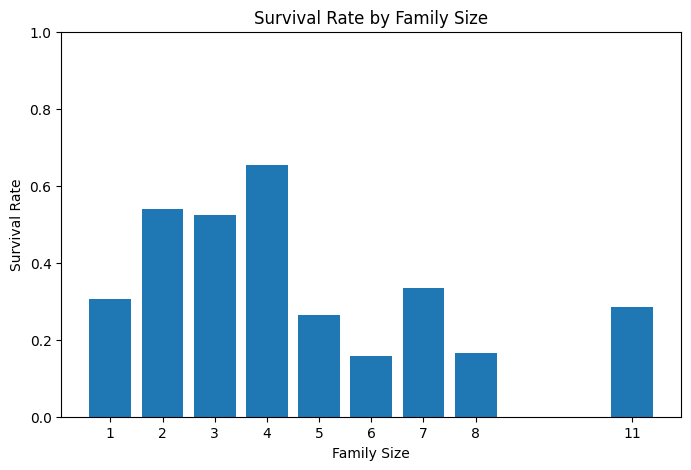

In [23]:
survival_rate = df_train_copy.groupby("familysize")["survived"].mean()

plt.figure(figsize=(8,5))
plt.bar(survival_rate.index, survival_rate.values)

plt.xlabel("Family Size")
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Family Size")

plt.xticks(survival_rate.index)
plt.ylim(0,1)

plt.show()

In [24]:
family_stats = df_train_copy.groupby("familysize").agg({
    "survived":"mean",
    "passengerid":"count"
}).rename(columns={
    "survived":"survival_rate",
    "passengerid":"count"
})

print(family_stats)

            survival_rate  count
familysize                      
1                0.304659    558
2                0.539877    163
3                0.522936    109
4                0.653846     26
5                0.263158     19
6                0.157895     19
7                0.333333      9
8                0.166667      6
11               0.285714      7
